In [50]:
%%writefile mpemba_lbm.cpp
#include <cmath>
#include <vector>
#include <iostream>
#include <algorithm>

const int Q = 27;
const double w[Q] = {
    8./27., 
    2./27., 2./27., 2./27., 2./27., 2./27., 2./27., 
    1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 
    1./216., 1./216., 1./216., 1./216., 1./216., 1./216., 1./216., 1./216.
};

const int cx[Q] = {0, 1,-1, 0, 0, 0, 0, 1,-1, 1,-1, 1,-1, 1,-1, 0, 0, 0, 0, 1,-1, 1,-1, 1,-1, 1,-1};
const int cy[Q] = {0, 0, 0, 1,-1, 0, 0, 1, 1,-1,-1, 0, 0, 0, 0, 1,-1, 1,-1, 1, 1,-1,-1, 1, 1,-1,-1};
const int cz[Q] = {0, 0, 0, 0, 0, 1,-1, 0, 0, 0, 0, 1, 1,-1,-1, 1, 1,-1,-1, 1, 1, 1, 1,-1,-1,-1,-1};
const int opp[Q] = {0, 2, 1, 4, 3, 6, 5, 10, 9, 8, 7, 14, 13, 12, 11, 18, 17, 16, 15, 26, 25, 24, 23, 22, 21, 20, 19};

extern "C" {

    void lbm_step(
        double* f, double* f_next, double* g, double* g_next,
        double* rho, double* ux, double* uy, double* uz, double* temp,
        int Nx, int Ny, int Nz, 
        double tau_f, double tau_g, 
        double beta1, double beta2, double g_grav, double T_ref,
        double k_term, double T_inf, double epsilon, double sigma,
        double C_evap, double C_clausius, double T_boil, double L_v_cp
    ) {
        int N = Nx * Ny * Nz;

        // --- PRECOMPUTACIÓN DE CONSTANTES FUERA DE LOS BUCLES ESPACIALES ---
        double omega_f = 1.0 / tau_f;
        double omega_g = 1.0 / tau_g;
        double eps_sigma = epsilon * sigma;
        double T_inf_4 = T_inf * T_inf * T_inf * T_inf;
        double inv_T_boil = 1.0 / T_boil;
        
        // La presión de saturación en el infinito es estática
        double P_sat_inf = std::exp(C_clausius * (inv_T_boil - 1.0 / T_inf));

        // --- BUCLE ÚNICO FUSIONADO (COLLIDE-AND-STREAM) ---
        for (int z = 0; z < Nz; ++z) {
            for (int y = 0; y < Ny; ++y) {
                for (int x = 0; x < Nx; ++x) {
                    int idx = z * Nx * Ny + y * Nx + x;

                    // 1. CÁLCULO MACROSCÓPICO
                    double loc_rho = 0.0, loc_ux = 0.0, loc_uy = 0.0, loc_uz = 0.0, loc_T = 0.0;
                    for (int i = 0; i < Q; ++i) {
                        int mem_idx = i * N + idx;
                        double fi = f[mem_idx]; // Lectura coalescida única
                        loc_rho += fi;
                        loc_ux  += fi * cx[i];
                        loc_uy  += fi * cy[i];
                        loc_uz  += fi * cz[i];
                        loc_T   += g[mem_idx];
                    }

                    if (loc_rho < 1e-6) loc_rho = 1e-6; 
                    double inv_rho = 1.0 / loc_rho; // División única
                    
                    loc_ux *= inv_rho; loc_uy *= inv_rho; loc_uz *= inv_rho;

                    double deltaT = loc_T - T_ref;
                    double Fz = loc_rho * g_grav * (beta1 * deltaT + beta2 * deltaT * deltaT);
                    loc_uz += (Fz * 0.5 * inv_rho);

                    double u2 = loc_ux*loc_ux + loc_uy*loc_uy + loc_uz*loc_uz;
                    double max_u2 = 0.01; 
                    if (u2 > max_u2) {
                        double scale = std::sqrt(max_u2 / u2);
                        loc_ux *= scale; loc_uy *= scale; loc_uz *= scale;
                        u2 = max_u2; 
                    }

                    // Guardar macroscópicas locales
                    rho[idx] = loc_rho; ux[idx] = loc_ux; uy[idx] = loc_uy; uz[idx] = loc_uz; temp[idx] = loc_T;

                    // 2. COLISIÓN Y PROPAGACIÓN SIMULTÁNEA (Push)
                    for (int i = 0; i < Q; ++i) {
                        int mem_idx = i * N + idx;
                        double cu = cx[i]*loc_ux + cy[i]*loc_uy + cz[i]*loc_uz;
                        
                        double feq = w[i] * loc_rho * (1.0 + 3.0*cu + 4.5*cu*cu - 1.5*u2);
                        double geq = w[i] * loc_T * (1.0 + 3.0*cu + 4.5*cu*cu - 1.5*u2);
                        double force_term = (1.0 - 0.5 * omega_f) * w[i] * 3.0 * Fz * cz[i];

                        // Estado post-colisión retenido en registros
                        double f_post = f[mem_idx] - omega_f * (f[mem_idx] - feq) + force_term;
                        double g_post = g[mem_idx] - omega_g * (g[mem_idx] - geq);

                        int next_x = x + cx[i];
                        int next_y = y + cy[i];
                        int next_z = z + cz[i];

                        // Condiciones de periodicidad laterales
                        if (next_x < 0) next_x = Nx - 1; else if (next_x >= Nx) next_x = 0;
                        if (next_y < 0) next_y = Ny - 1; else if (next_y >= Ny) next_y = 0;

                        if (next_z < 0) {
                            // FRONTERA INFERIOR: Newton-Raphson Optimizado
                            double T_wall = loc_T; 
                            const double tol = 1e-6;
                            
                            for (int iter = 0; iter < 10; ++iter) {
                                double T_w2 = T_wall * T_wall;
                                double T_w3 = T_w2 * T_wall;
                                double F = k_term * (loc_T - T_wall) - eps_sigma * (T_w3 * T_wall - T_inf_4);
                                double dF = -k_term - 4.0 * eps_sigma * T_w3;
                                double delta = F / dF;
                                T_wall -= delta;
                                
                                if (T_wall < T_inf) T_wall = T_inf; 
                                if (std::abs(delta) < tol) break;
                            }

                            int o_i = opp[i];
                            int mem_opp_curr = o_i * N + idx;
                            
                            f_next[mem_opp_curr] = f_post; 
                            g_next[mem_opp_curr] = std::max(0.0, -g_post + 2.0 * w[o_i] * T_wall); 
                        } 
                        else if (next_z >= Nz) {
                            // FRONTERA SUPERIOR: Evaporación Optimizada
                            int o_i = opp[i];
                            int mem_opp_curr = o_i * N + idx;
                            
                            double evap_fraction = 0.0;
                            
                            if (loc_T > T_inf) {
                                double P_sat_fluid = std::exp(C_clausius * (inv_T_boil - 1.0 / loc_T));
                                evap_fraction = C_evap * std::max(0.0, P_sat_fluid - P_sat_inf);
                                if (evap_fraction > 1.0) evap_fraction = 1.0; 
                            }

                            double delta_m_local = f_post * evap_fraction;
                            f_next[mem_opp_curr] = f_post - delta_m_local;
                            
                            double q_evap_T = (delta_m_local * L_v_cp) * inv_rho;
                            g_next[mem_opp_curr] = std::max(0.0, g_post - 2.0 * w[o_i] * q_evap_T);
                        } 
                        else {
                            // DOMINIO INTERNO: Streaming Directo
                            int idx_next = next_z * Nx * Ny + next_y * Nx + next_x;
                            f_next[i * N + idx_next] = f_post;
                            g_next[i * N + idx_next] = g_post;
                        }
                    }
                }
            }
        }
    }
}

Overwriting mpemba_lbm.cpp


In [51]:
!g++ -O3 -ffast-math -funroll-loops -shared -fPIC -std=c++14 mpemba_lbm.cpp -o libmpemba.so

In [53]:
import ctypes
import numpy as np
import matplotlib.pyplot as plt
import concurrent.futures
import time
import multiprocessing

def init_worker(lock):
    global print_lock
    print_lock = lock

def run_simulation(initial_T_celsius):
    lib = ctypes.CDLL('./libmpemba.so')
    lib.lbm_step.argtypes = [
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        np.ctypeslib.ndpointer(dtype=np.float64, ndim=1, flags='C_CONTIGUOUS'),
        ctypes.c_int, ctypes.c_int, ctypes.c_int,
        ctypes.c_double, ctypes.c_double,
        ctypes.c_double, ctypes.c_double, ctypes.c_double, ctypes.c_double,
        ctypes.c_double, ctypes.c_double, ctypes.c_double, ctypes.c_double,
        ctypes.c_double, ctypes.c_double, ctypes.c_double, ctypes.c_double
    ]

    Nx, Ny, Nz = 32, 32, 32
    Q, N_total = 27, Nx * Ny * Nz

    # Parámetros físicos inalterados según tu solicitud
    sigma = 5.670374e-8  
    epsilon = 0.95
    tau_f = 0.55
    tau_g = 0.85         
    beta1, beta2 = 0, 5.0e-5 
    g_grav, k_term = 9.81 / 1000.0, 0.8  
    
    T_ref = 277.15  
    
    T_inf_celsius = -5.0
    T_inf = T_inf_celsius + 273.15  

    T_boil = 373.15
    C_clausius = 2260000.0 / 461.5       
    L_v_cp = 150000.0         
    C_evap = 0.05    

    initial_T = initial_T_celsius + 273.15  

    w = np.array([
        8./27., 2./27., 2./27., 2./27., 2./27., 2./27., 2./27., 
        1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 1./54., 
        1./216., 1./216., 1./216., 1./216., 1./216., 1./216., 1./216., 1./216.
    ], dtype=np.float64)

    f = np.zeros(Q * N_total, dtype=np.float64)
    f_next = np.zeros(Q * N_total, dtype=np.float64)
    g = np.zeros(Q * N_total, dtype=np.float64)
    g_next = np.zeros(Q * N_total, dtype=np.float64)

    rho = np.ones(N_total, dtype=np.float64)
    ux, uy, uz = [np.zeros(N_total, dtype=np.float64) for _ in range(3)]
    temp = np.ones(N_total, dtype=np.float64) * initial_T

    for i in range(Q):
        f[i * N_total : (i + 1) * N_total] = w[i] * 1.0
        f_next[i * N_total : (i + 1) * N_total] = w[i] * 1.0
        g[i * N_total : (i + 1) * N_total] = w[i] * initial_T
        g_next[i * N_total : (i + 1) * N_total] = w[i] * initial_T

    steps = 4000 
    historial_T = []
    historial_Masa = []
    masa_inicial = np.sum(rho)
    
    with print_lock:
        print(f"\n[{initial_T_celsius}°C] Iniciando Simulación (T_inf = {T_inf_celsius}°C)...")
        print(f"[{initial_T_celsius}°C] {'Paso':<6} | {'T. Media (°C)':<15} | {'Masa Remanente':<15} | {'Pérdida Masa (%)'}")
        print("-" * 65)

    for step in range(steps):
        lib.lbm_step(
            f, f_next, g, g_next, rho, ux, uy, uz, temp, 
            Nx, Ny, Nz, tau_f, tau_g, beta1, beta2, g_grav, T_ref, 
            k_term, T_inf, epsilon, sigma,
            C_evap, C_clausius, T_boil, L_v_cp
        )
        f, f_next = f_next, f
        g, g_next = g_next, g

        if step % 100 == 0:
            t_mean_c = np.mean(temp) - 273.15
            masa_actual = np.sum(rho)
            perdida_pct = (masa_inicial - masa_actual) / masa_inicial * 100.0
            
            historial_T.append(t_mean_c)
            historial_Masa.append(masa_actual)
            
            with print_lock:
                if np.isnan(t_mean_c):
                    print(f"[{initial_T_celsius}°C] >>> COLAPSO NUMÉRICO (NaN) detectado en paso {step} <<<")
                    break
                else:
                    print(f"[{initial_T_celsius}°C] {step:<6} | {t_mean_c:<15.4f} | {masa_actual:<15.2f} | {perdida_pct:.4f}%")

    with print_lock:
        print(f"[{initial_T_celsius}°C] Finalizado.\n")
        
    return initial_T_celsius, historial_T, historial_Masa

if __name__ == '__main__':
    temperaturas_prueba = [90.0, 30.0] 
    resultados = {}

    m = multiprocessing.Manager()
    l = m.Lock()

    print("Despachando procesos paralelos (Multiprocessing)...")
    start_time = time.time()

    with concurrent.futures.ProcessPoolExecutor(max_workers=2, initializer=init_worker, initargs=(l,)) as executor:
        futuros = {executor.submit(run_simulation, T): T for T in temperaturas_prueba}
        
        for futuro in concurrent.futures.as_completed(futuros):
            T_base = futuros[futuro]
            try:
                t_ini, hist_T, hist_M = futuro.result()
                resultados[t_ini] = (hist_T, hist_M)
            except Exception as exc:
                with l:
                    print(f"\n[ERROR CRÍTICO] El hilo de {T_base}°C generó una excepción: {exc}\n")

    end_time = time.time()
    print(f"Tiempo total de simulación paralela: {end_time - start_time:.2f} segundos.")

    # ---------------------------------------------------------
    # 1. EXPORTACIÓN DE DATOS (Archivo .dat)
    # ---------------------------------------------------------
    dat_filename = "resultados_mpemba.dat"
    with open(dat_filename, "w") as f:
        # Escribir cabeceras dinámicamente ordenadas (Mayor a Menor Temp)
        temps_ordenadas = sorted(resultados.keys(), reverse=True)
        cabecera = "Paso\t" + "\t".join([f"Temp_{t}C\tMasa_{t}C" for t in temps_ordenadas]) + "\n"
        f.write(cabecera)
        
        # Asumiendo que ambas simulaciones tienen la misma cantidad de pasos registrados
        pasos_registrados = len(resultados[temps_ordenadas[0]][0])
        
        for i in range(pasos_registrados):
            paso_temporal = i * 100 # Multiplicador según el muestreo (step % 100 == 0)
            fila = f"{paso_temporal}\t"
            for t_ini in temps_ordenadas:
                temp_val = resultados[t_ini][0][i]
                masa_val = resultados[t_ini][1][i]
                fila += f"{temp_val:.4f}\t{masa_val:.2f}\t"
            f.write(fila.strip() + "\n")
            
    print(f"Datos exportados exitosamente a: {dat_filename}")

    # ---------------------------------------------------------
    # 2. EXPORTACIÓN DE GRÁFICAS (Imágenes .png separadas a 300 DPI)
    # ---------------------------------------------------------
    colores = {90.0: 'firebrick', 30.0: 'dodgerblue'}
    etiquetas = {90.0: 'Muestra Caliente (90°C)', 30.0: 'Muestra Fría (30°C)'}
    
    eje_x = np.arange(pasos_registrados) * 100  

    # --- Gráfica 1: Temperatura ---
    fig_T, ax_T = plt.subplots(figsize=(8, 6))
    for t_ini in temps_ordenadas:
        hist_T = resultados[t_ini][0]
        ax_T.plot(eje_x, hist_T, color=colores[t_ini], label=etiquetas[t_ini], linewidth=2.5)

    ax_T.set_title('Efecto Mpemba: Perfil Térmico Macroscópico', fontsize=14)
    ax_T.set_xlabel('Pasos Temporales ($\Delta t$)', fontsize=12)
    ax_T.set_ylabel('Temperatura Media (°C)', fontsize=12)
    ax_T.axhline(0, color='black', linestyle='--', alpha=0.6, label='Punto Congelación (0°C)')
    ax_T.axhline(-5.0, color='purple', linestyle=':', alpha=0.8, label='Ambiente (-5°C)')
    ax_T.grid(True, alpha=0.4)
    ax_T.legend(fontsize=10)
    plt.tight_layout()
    
    nombre_fig_T = "grafica_temperatura_mpemba.png"
    fig_T.savefig(nombre_fig_T, dpi=300, bbox_inches='tight')
    print(f"Gráfica térmica exportada: {nombre_fig_T}")
    plt.close(fig_T) # Cerrar para liberar memoria

    # --- Gráfica 2: Decaimiento de Masa ---
    fig_M, ax_M = plt.subplots(figsize=(8, 6))
    for t_ini in temps_ordenadas:
        hist_M = resultados[t_ini][1]
        masa_relativa = (np.array(hist_M) / hist_M[0]) * 100.0 
        ax_M.plot(eje_x, masa_relativa, color=colores[t_ini], label=etiquetas[t_ini], linewidth=2.5)

    ax_M.set_title('Decaimiento de Masa Relativa (Evaporación)', fontsize=14)
    ax_M.set_xlabel('Pasos Temporales ($\Delta t$)', fontsize=12)
    ax_M.set_ylabel('Masa Restante (%)', fontsize=12)
    ax_M.grid(True, alpha=0.4)
    ax_M.legend(fontsize=10)
    plt.tight_layout()
    
    nombre_fig_M = "grafica_masa_mpemba.png"
    fig_M.savefig(nombre_fig_M, dpi=300, bbox_inches='tight')
    print(f"Gráfica de masa exportada: {nombre_fig_M}")
    plt.close(fig_M)

    print("Proceso de simulación y post-procesamiento finalizado con éxito.")

<>:179: SyntaxWarning: invalid escape sequence '\D'
<>:200: SyntaxWarning: invalid escape sequence '\D'
<>:179: SyntaxWarning: invalid escape sequence '\D'
<>:200: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2507/1448391935.py:179: SyntaxWarning: invalid escape sequence '\D'
  ax_T.set_xlabel('Pasos Temporales ($\Delta t$)', fontsize=12)
/tmp/ipykernel_2507/1448391935.py:200: SyntaxWarning: invalid escape sequence '\D'
  ax_M.set_xlabel('Pasos Temporales ($\Delta t$)', fontsize=12)


Despachando procesos paralelos (Multiprocessing)...

[90.0°C] Iniciando Simulación (T_inf = -5.0°C)...
[90.0°C] Paso   | T. Media (°C)   | Masa Remanente  | Pérdida Masa (%)
-----------------------------------------------------------------

[30.0°C] Iniciando Simulación (T_inf = -5.0°C)...
[30.0°C] Paso   | T. Media (°C)   | Masa Remanente  | Pérdida Masa (%)
-----------------------------------------------------------------
[30.0°C] 0      | 30.0000         | 32768.00        | 0.0000%
[90.0°C] 0      | 90.0000         | 32768.00        | 0.0000%
[30.0°C] 100    | 22.6930         | 32758.60        | 0.0287%
[90.0°C] 100    | 63.1069         | 32699.46        | 0.2092%
[30.0°C] 200    | 19.4054         | 32754.16        | 0.0422%
[90.0°C] 200    | 54.6275         | 32680.90        | 0.2658%
[30.0°C] 300    | 16.8602         | 32750.83        | 0.0524%
[90.0°C] 300    | 48.2838         | 32668.42        | 0.3039%
[30.0°C] 400    | 14.6962         | 32748.12        | 0.0607%
[90.0°C] 400  

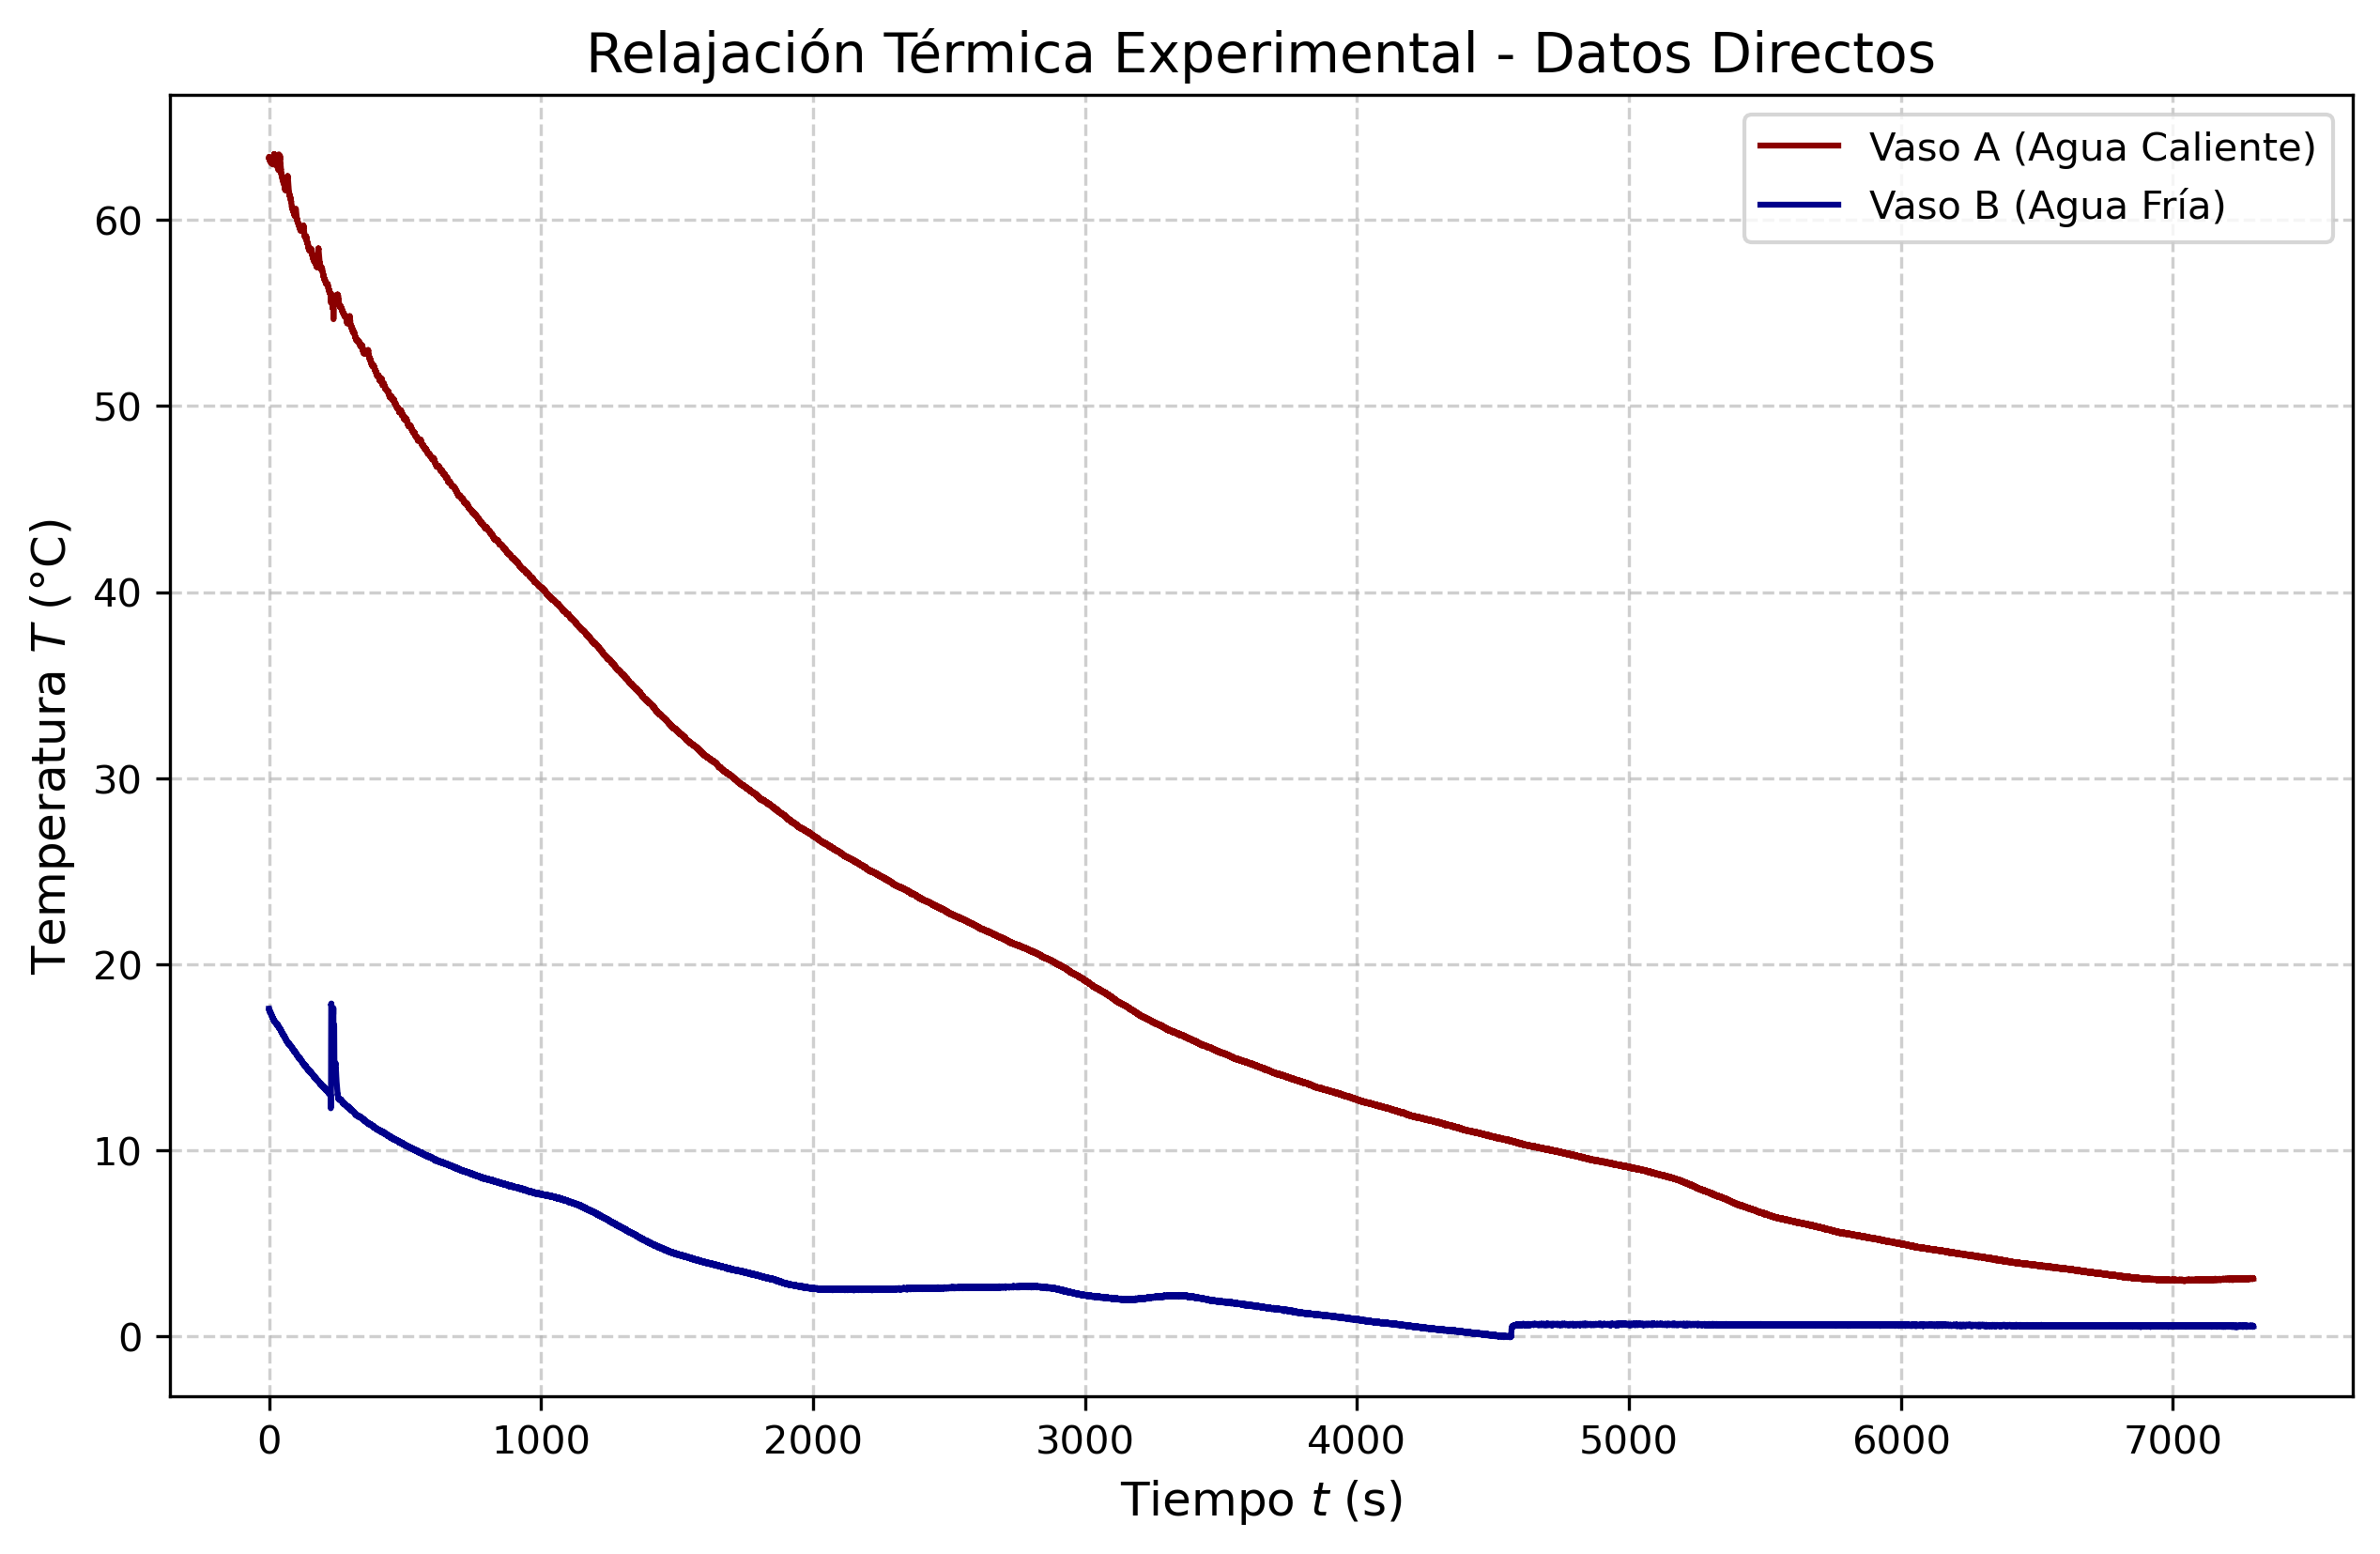